# 03. TPE Force Vector Solver

**Pipeline step 3 of 3** — uses a ResNet regression model to make initial force/angle guesses at each contact, then refines them by minimising the difference between the synthetic photoelastic image and the experimental image subject to force/torque equilibrium constraints.

## Inputs
- Trajectory `.pkl` from Step 1
- Contact bond `.pkl` from Step 2
- Pre-trained ResNet18 weights (`models/Contact_Force_ResNet_*.pth`)
- Photoelastic images (`bw_*.png`)

## Outputs
- `PREDICTION_<EXP_NAME>.pkl` — ResNet initial guesses (force, angle) per contact
- `FORCE_FITTED_TEMP_<EXP_NAME>.csv` — fitted (force, alpha) per contact, appended frame-by-frame
- `<EXP_NAME>_Force_ResNet.pkl` — final corrected and symmetric force dataset

## Workflow
1. Crop contact ROIs and run ResNet → initial (force, angle) guesses
2. For each particle: optimise (force, alpha) to match the photoelastic image
3. Validate reciprocity (ij vs ji), symmetrise using the better-fitting side
4. Save

### Imports

In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import sys
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torchvision import transforms
import concurrent.futures as cf
import time

sys.path.insert(0, os.getcwd())
import src


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Parameters — edit here before running

In [2]:
EXP_NAME  = 'TPE_20260414A01_N=262x2_e-4rps_e-1fps_steady_e3frames'

IMG_DIR  = os.path.join(r'N:\PROJ_TPE', EXP_NAME)
TRAJ_DIR = r'M:\Archive\Proj_TPE\Disk_traj_files'
BOND_DIR = r'M:\Archive\Proj_TPE\Contact_bond_files'
OUT_DIR  = r'M:\Archive\Proj_TPE\Force Inversion'

frame_lag = 0  # image index offset between trajectory frames and PE images

# Derived paths
traj_filename = os.path.join(TRAJ_DIR, f'{EXP_NAME}.pkl')
bond_filename = os.path.join(BOND_DIR,  f'CONTACT_BOND_{EXP_NAME}.pkl')

F_bond = pd.read_pickle(bond_filename)
F_traj = pd.read_pickle(traj_filename)

# Load force prediction model
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = os.path.join(os.getcwd(), 'models', 'Contact_Force_ResNet_20260130.pth')
model      = src.get_model(DEVICE)
model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
model.eval()

print(f"Model loaded: {model_path}")
print(f"Running on:   {DEVICE}")

Model loaded: o:\LJJ202107\LJJ Jupyter Notebook Collection\TPE_image_process_pipeline\models\Contact_Force_ResNet_20260130.pth
Running on:   cuda


### Make initial guess for forces and angles

First crop and append all ROIs, append to list.
Then make initial guess in batches, append back to F_bond (~ 30 min)

In [ ]:
# Define transforms (same as training)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

ROI_BATCH_SIZE = 256      # CPU-side ROI accumulation batch
INFER_BATCH_SIZE = 64     # GPU/CPU inference mini-batch

model.eval()

############### Initialize output frame ###############
F_bond_pred = F_bond.copy()
F_bond_pred['force_pred'] = np.nan
F_bond_pred['angle_pred'] = np.nan

total_contacts = len(F_bond_pred)
print(f"Starting streaming ROI extraction (roi_batch={ROI_BATCH_SIZE})", flush=True)
print(f"Inference mini-batch={INFER_BATCH_SIZE} on device={DEVICE}", flush=True)
print(f"Total contacts to predict: {total_contacts}", flush=True)

############################# STREAMED MODEL PREDICTION ###############################
processed_contacts = 0
chunk_id = 0

with torch.no_grad():
    for chunk_images, chunk_meta, total_seen in src.iter_contact_roi_batches(
        F_bond, IMG_DIR, frame_lag=frame_lag, batch_size=ROI_BATCH_SIZE
    ):
        chunk_id += 1

        for start in range(0, len(chunk_images), INFER_BATCH_SIZE):
            end = min(start + INFER_BATCH_SIZE, len(chunk_images))
            batch_imgs = [data_transform(src.to_pil_uint8(im)) for im in chunk_images[start:end]]
            batch_tensor = torch.stack(batch_imgs).to(DEVICE)
            batch_predictions = model(batch_tensor).cpu().numpy()

            idxs = [m['idx'] for m in chunk_meta[start:end]]
            F_bond_pred.loc[idxs, 'force_pred'] = batch_predictions[:, 0]
            F_bond_pred.loc[idxs, 'angle_pred'] = batch_predictions[:, 1]

            del batch_tensor, batch_imgs, batch_predictions
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        del chunk_images, chunk_meta



Prediction complete: 0/403622 (100.0%)


In [7]:
# Write F_bond_pred to pickle
output_path = os.path.join(OUT_DIR, f'PREDICTION_{EXP_NAME}.pkl')
F_bond_pred.to_pickle(output_path)

### Fitting configuration

Setting knobs for fitting are shown first for convenience. Most don't require tuning and can be left as is.

Turn on 'plot_every' to visualise the fitting process for each particle

In [8]:
fsigma = 225 #photoelastic constant
plot_every = 0  # Plotting is only supported in sequential mode (GPU_PARALLEL_WORKERS == 1)
verbose = 0

# GPU parallelism knob: number of particles to fit concurrently per frame
GPU_PARALLEL_WORKERS = 4

############## FITTING HYPERPARAMS, TUNE WITH CARE ##############
tol=1e-3
patience=10
lr=4e-2
n_iter=1000
############## DEVICE CHECK ##############

if DEVICE.type != 'cuda':
    raise RuntimeError('This cell is configured for GPU-only fitting. Set DEVICE to cuda before running.')
if GPU_PARALLEL_WORKERS > 1 and plot_every:
    print('plot_every is disabled when GPU_PARALLEL_WORKERS > 1 to avoid threaded matplotlib issues.')

# Keep fit args in one place so submit/retry paths stay compact
fit_kwargs = dict(
    device=DEVICE,
    lr=lr,
    n_iter=n_iter,
    tol=tol,
    patience=patience,
    verbose=verbose,
 )

def run_fit(pid, pdata, img, do_plot=False):
    return src.fit_one_particle_gpu(
        pid, pdata, img, fsigma,
        do_plot=do_plot,
        **fit_kwargs,
    )


### Starts fitting 

In [9]:
############################## PATHS AND LOGISTICS ###################################

output_csv_path = os.path.join(OUT_DIR, f'FORCE_FITTED_TEMP_{EXP_NAME}.csv')

F_bond_pred = pd.read_pickle(os.path.join(OUT_DIR, f'PREDICTION_{EXP_NAME}.pkl'))
F_bond_pred = src.append_ij_angle_to_pdata(F_bond_pred)

# Determine whether we should resume from existing CSV
all_frames = sorted(F_bond_pred['frame'].unique())
frames_to_process = all_frames

if os.path.exists(output_csv_path):
    try:
        existing = pd.read_csv(output_csv_path, usecols=['frame'])
        existing = existing.dropna(subset=['frame'])

        if len(existing) > 0:
            last_processed_frame = int(existing['frame'].max())
            frames_to_process = [f for f in all_frames if f > last_processed_frame]
            print(f"Resuming from existing CSV. Last processed frame: {last_processed_frame}")
            print(f"Frames remaining: {len(frames_to_process)}")
        else:
            print('Existing CSV is empty. Starting from first frame.')
    except Exception as e:
        print(f"Could not read existing CSV ({e}). Starting from first frame.")

if len(frames_to_process) == 0:
    print(f"No new frames to process. Existing results are up to date: {output_csv_path}")

########################## Main loop: process frames and fit particles in parallel on GPU ##########################
#for frame in frames_to_process:
for frame in [682]:
    frame_t0 = time.perf_counter()
    print(f"\rProcessing frame: {frame}", end='', flush=True)

    frame_data_out = []

    image_path = os.path.join(IMG_DIR, 'bw_' + str(frame + frame_lag) + '.png')
    img, img_err = src.read_image_with_retry(image_path, retries=4, delay_s=0.15)
    if img is None:
        print(f"\rFrame {frame} skipped | image read failed: {image_path} | reason: {img_err}")
        continue

    frame_data = F_bond_pred[F_bond_pred['frame'] == frame]
    particle_groups = [(pid, pdata) for pid, pdata in frame_data.groupby('i') if len(pdata) > 1]
    n_candidates = len(particle_groups)
    n_failed = 0

    if n_candidates == 0:
        frame_dt = time.perf_counter() - frame_t0
        print(f"\rFrame {frame} done | fitted=0/0 | failed=0 | time={frame_dt:.2f}s")
        continue

    if GPU_PARALLEL_WORKERS > 1:
        with cf.ThreadPoolExecutor(max_workers=GPU_PARALLEL_WORKERS) as ex:
            future_to_payload = {
                ex.submit(run_fit, pid, pdata, img, False): (pid, pdata)
                for pid, pdata in particle_groups
            }

            for fut in cf.as_completed(future_to_payload):
                pid, pdata = future_to_payload[fut]
                try:
                    res = fut.result()
                except Exception as e:
                    n_failed += 1
                    if verbose:
                        print(f"\nWorker failed at frame={frame}, particle={pid}: {e}")
                    try:
                        # Retry once in the main thread to reduce transient thread/CUDA failures.
                        res = run_fit(pid, pdata, img, False)
                    except Exception as e2:
                        if verbose:
                            print(f"\nRetry failed at frame={frame}, particle={pid}: {e2}")
                        res = None

                if res is not None:
                    frame_data_out.append(res)
    else:
        for pid, pdata in particle_groups:
            try:
                res = run_fit(pid, pdata, img, bool(plot_every))
            except Exception as e:
                n_failed += 1
                if verbose:
                    print(f"\nSequential fit failed at frame={frame}, particle={pid}: {e}")
                res = None
            if res is not None:
                frame_data_out.append(res)

    n_fitted = len(frame_data_out)

    if frame_data_out:
        frame_data_out.sort(key=lambda x: x[0])
        frame_results = pd.concat([x[1] for x in frame_data_out], ignore_index=True)

        write_header = (not os.path.exists(output_csv_path)) or os.path.getsize(output_csv_path) == 0
        frame_results.to_csv(output_csv_path, mode='a', header=write_header, index=False)

    frame_dt = time.perf_counter() - frame_t0
    print(f"\rFrame {frame} done | fitted={n_fitted}/{n_candidates} | failed={n_failed} | time={frame_dt:.2f}s")

print(f"\nProcessing complete! Results saved to: {output_csv_path}")

Frame 682 done | fitted=130/130 | failed=0 | time=55.54s

Processing complete! Results saved to: M:\Archive\Proj_TPE\Force Inversion\FORCE_FITTED_TEMP_TPE_20260414A01_N=262x2_e-4rps_e-1fps_steady_e3frames.csv


### Calculate ij/ji force difference, make all f and alpha equal to the one with smaller fitLoss

Total contacts: 395
Contacts with reciprocal pairs corrected: 176
Contacts without reciprocal pairs (unchanged): 219


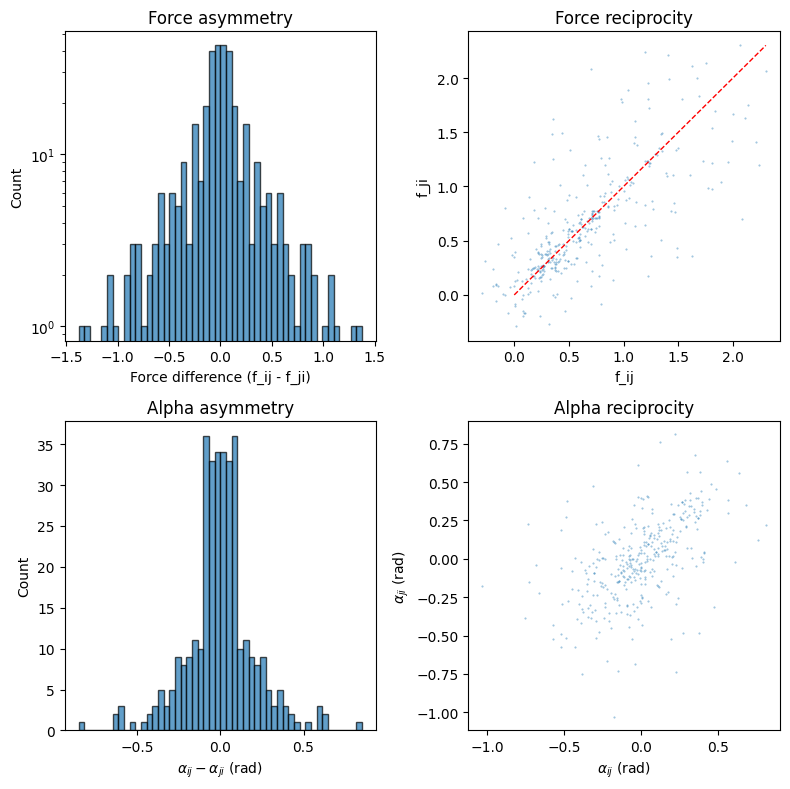

In [3]:
# Load fitted results, run reciprocity analysis + symmetrization, then plot ij/ji diagnostics
F_bond_out = pd.read_csv(os.path.join(OUT_DIR, f'FORCE_FITTED_TEMP_{EXP_NAME}.csv'))

F_compare, F_bond_corrected, correction_stats = src.symmetrize_forces(F_bond_out)

print(f"Total contacts: {correction_stats['total_contacts']}")
print(f"Contacts with reciprocal pairs corrected: {correction_stats['reciprocal_pairs']}")
print(f"Contacts without reciprocal pairs (unchanged): {correction_stats['contacts_unchanged']}")

fig = plt.figure(figsize=(8, 8))

# Force difference histogram
plt.subplot(2, 2, 1)
plt.hist(F_compare['force_diff'], bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('Force difference (f_ij - f_ji)')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Force asymmetry')

# Force reciprocity scatter
plt.subplot(2, 2, 2)
plt.scatter(F_compare['force'], F_compare['force_ji'], s=0.2, alpha=0.5)
plt.plot([0, F_compare['force'].max()], [0, F_compare['force'].max()], 'r--', lw=1)
plt.xlabel('f_ij')
plt.ylabel('f_ji')
plt.title('Force reciprocity')

# Alpha difference histogram
plt.subplot(2, 2, 3)
plt.hist(F_compare['alpha_diff_norm'], bins=50, edgecolor='k', alpha=0.7)
plt.xlabel(r'$\alpha_{ij} - \alpha_{ji}$ (rad)')
plt.ylabel('Count')
plt.title('Alpha asymmetry')

# Alpha reciprocity scatter
plt.subplot(2, 2, 4)
plt.scatter(F_compare['alpha'], F_compare['alpha_ji'], s=0.2, alpha=0.5)
plt.xlabel(r'$\alpha_{ij}$ (rad)')
plt.ylabel(r'$\alpha_{ji}$ (rad)')
plt.title('Alpha reciprocity')
plt.axis('equal')

plt.tight_layout()
plt.show()


### Check results by drawing full-field synth img from fitted resuls

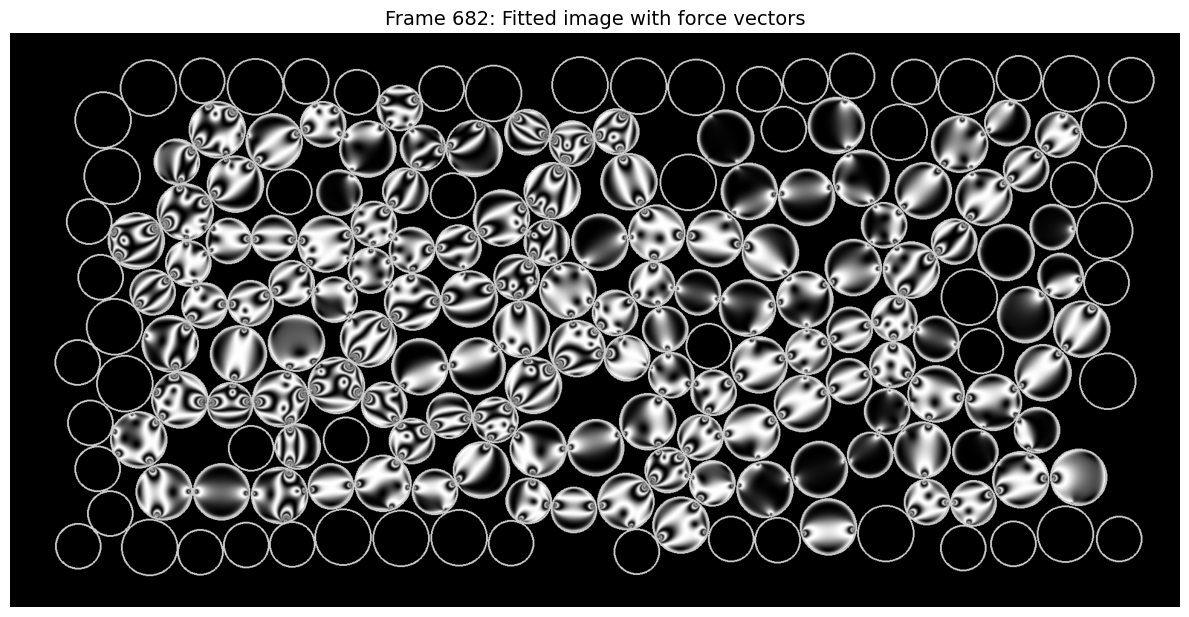

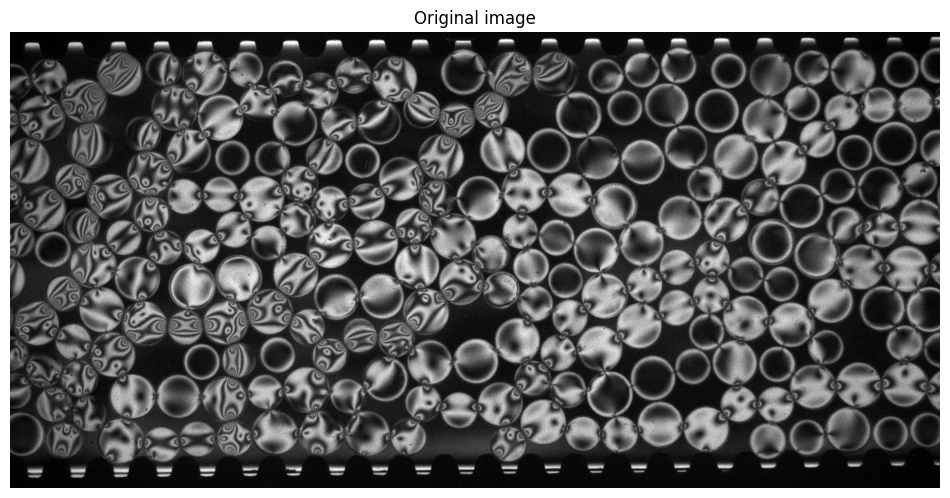

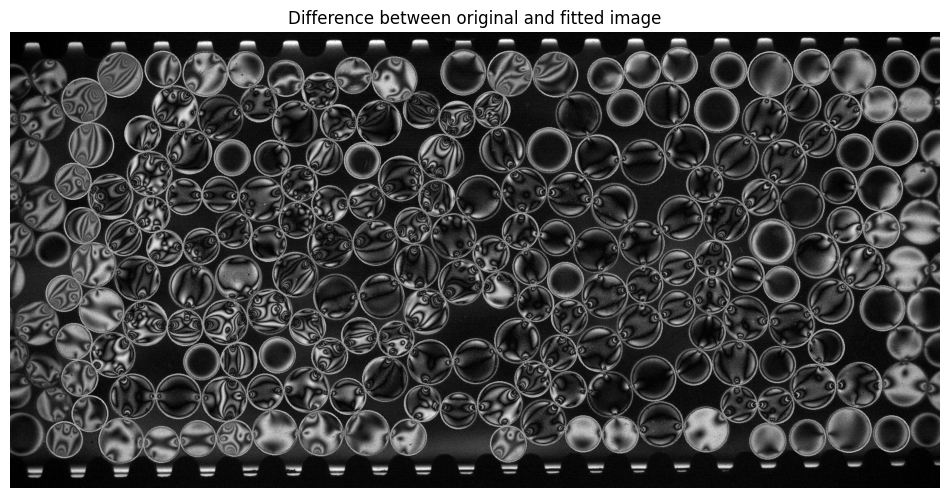

In [7]:
frame = np.random.choice(F_bond_corrected['frame'].unique())
f = F_bond_corrected[F_bond_corrected.frame==frame].copy()

# Load the original PE image
image_path = os.path.join(IMG_DIR, 'bw_'+str(frame+frame_lag)+'.png')
orig_img = cv2.imread(image_path)
orig_img = orig_img[250:1200, :]  # Apply the same crop as in get_img_and_force

# Build synthesized field from fitted contacts
output_img = src.build_particle_synth_output_img(f, orig_img, fsigma=225, device=DEVICE)

# Plot empty circles for disks without contacts
all_particle = F_traj[F_traj.frame==frame]

for _, row in all_particle.iterrows():
    cx = int(round(float(row.x)))
    cy = int(round(float(row.y)))
    center = (cx, cy)
    radius = int(round(float(row.rpx)))

    h_out, w_out = output_img.shape[:2]
    if radius <= 0 or cx < 0 or cy < 0 or cx >= w_out or cy >= h_out:
        continue

    color = 0.8
    thickness = 2

    if output_img.ndim == 3 and output_img.shape[2] == 3:
        cv2.circle(output_img, center, radius, (color, color, color), thickness)
    else:
        cv2.circle(output_img, center, radius, color, thickness)

final_img = output_img

orig_img = orig_img/orig_img.max()
diff_img = cv2.absdiff((orig_img).astype(np.float32), final_img.astype(np.float32))

# Plot 1: All fitted balls overlaid with force vectors
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(final_img.astype(np.float32), cmap='gray')
ax.set_xlim(0, final_img.shape[1])
ax.set_ylim(final_img.shape[0], 0)
ax.axis('off')
ax.set_title(f'Frame {frame}: Fitted image with force vectors', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Original image
plt.figure(figsize=(12, 12))
plt.imshow((orig_img).astype(np.float32), cmap='gray')
plt.title('Original image')
plt.axis('off')
plt.show()

# Plot 3: Difference between original and fitted
plt.figure(figsize=(12, 12))
plt.imshow(diff_img, cmap='gray')
plt.title('Difference between original and fitted image')
plt.axis('off')
plt.show()


### Save to disk

In [32]:
# Optional: Convert CSV to pickle for faster loading in future analyses
out_filename = os.path.join(OUT_DIR, EXP_NAME + '_Force_ResNet.pkl')
F_bond_corrected.to_pickle(out_filename)
print(f"Saved final corrected results to: {out_filename}")

Saved final corrected results to: M:\Archive\Proj_TPE\Force Inversion\TPE_20260413A01_N=262x2_e-2rps_10fps_steady_e3frames_Force_ResNet.pkl
